In [2]:
# This is timport datarobot as dr
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import sys, os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
import xgboost as xgb
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from xgboost.callback import EarlyStopping

# Go up one directory from "notebooks" to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from scripts.modeling import (rank_models,
                              split_dataset,
                                plot_roc_curve_from_df) 


from scripts.utils import (save_file) 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [3]:
# import sys
# print(sys.executable)

# !{sys.executable} -m pip install lightgbm

In [4]:
# import sys
# print(sys.executable)

# !{sys.executable} -m pip install xgboost

# 1 Ingests Data 

In [5]:
# Build base directory (go up one level from current /02_scripts)
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos
base_dir_raw =  Path(base_dir)
base_dir_raw= str(base_dir_raw.parents[1])

In [6]:
# Build the path to the target CSV
csv_path_Modulo1631_REC91_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1631_REC91_2024_M_clear_v3.csv")
csv_path_Modulo1635_RE516171_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1635_RE516171_2024_M_clear_v3.csv")
csv_path_Modulo1632_RE223132_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1632_RE223132_2024_M_clear_v3.csv")
csv_path_Modulo1633_REC41_2024_fil_clear_v2 = os.path.join(base_dir,"data\\interim", "Modulo1633_REC41_2024_fil_clear_v3.csv")
csv_path_Modulo1633_REC94_2024_fil_clear_v2 = os.path.join(base_dir,"data\\interim", "Modulo1633_REC94_2024_fil_clear_v3.csv")
csv_path_Modulo1640_CSALUD01_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1640_CSALUD01_2024_M_clear_v3.csv")
csv_path_target_final = os.path.join(base_dir,"data\\interim", "target_final.csv")

# Load the CSV into a DataFrame
Modulo1631_REC91_2024_M_clear = pd.read_csv(csv_path_Modulo1631_REC91_2024_M_clear, low_memory=False)
Modulo1635_RE516171_2024_M_clear= pd.read_csv(csv_path_Modulo1635_RE516171_2024_M_clear, low_memory=False)
Modulo1632_RE223132_2024_M_clear= pd.read_csv(csv_path_Modulo1632_RE223132_2024_M_clear, low_memory=False)
Modulo1633_REC41_2024_fil_clear_v2= pd.read_csv(csv_path_Modulo1633_REC41_2024_fil_clear_v2, low_memory=False)
Modulo1633_REC94_2024_fil_clear_v2= pd.read_csv(csv_path_Modulo1633_REC94_2024_fil_clear_v2, low_memory=False)
Modulo1640_CSALUD01_2024_M_clear= pd.read_csv(csv_path_Modulo1640_CSALUD01_2024_M_clear, low_memory=False)
target_final = pd.read_csv(csv_path_target_final, low_memory=False)


print(Modulo1631_REC91_2024_M_clear.shape)
print(Modulo1635_RE516171_2024_M_clear.shape)
print(Modulo1632_RE223132_2024_M_clear.shape)
print(Modulo1633_REC41_2024_fil_clear_v2.shape)
print(Modulo1633_REC94_2024_fil_clear_v2.shape) 
print(Modulo1640_CSALUD01_2024_M_clear.shape) 
print(target_final.shape) 

(37117, 133)
(34252, 64)
(34252, 66)
(18335, 90)
(18335, 54)
(34018, 97)
(18335, 5)


In [7]:
Modulo1631_REC91_2024_M_clear.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37117 entries, 0 to 37116
Data columns (total 133 columns):
 #    Column          Dtype  
---   ------          -----  
 0    CASEID          object 
 1    S1002C          float64
 2    SPROVIN         float64
 3    S802            float64
 4    S1034B          float64
 5    S806AZ          float64
 6    S1033           float64
 7    SREGION         float64
 8    S1026           float64
 9    S119            float64
 10   S119D           float64
 11   S807            float64
 12   S802D           float64
 13   S1002E          float64
 14   SDISTRI         float64
 15   S802I           float64
 16   S108N           float64
 17   S1002B          float64
 18   S1002D          float64
 19   S1034A          float64
 20   S809            float64
 21   S704N           float64
 22   S119NA          float64
 23   S806AX          float64
 24   S1002A          float64
 25   S119NB          float64
 26   S802F           float64
 27   S802E         

In [8]:
RANK_Modulo1631_REC91_2024_M_clear = ['SREGION','CASEID',
'S108N',
'S119',
'S119D',
'S704N',
'S816W',
'S816G',
'S816B',
'S816AL',
'S500B',
# 'S229A1',
# 'S229Y',
# 'S229A'
]



RANK_Modulo1635_RE516171_2024_M_clear =['CASEID',
    'V704',
'V715',
'V501',
'V716',
'V511',
'V631',
'V732',
'V504',
'V743F',
'V531',
'V525',
'V717',
'V743E',
'V743A',
'V702',
'V721',
'V705',


]
RANK_Modulo1632_RE223132_2024_M_clear = ['CASEID',
    'V212',
'V228',
'V218',
'V208',
'V217',
'V364',

]

RANK_Modulo1633_REC41_2024_fil_v2 =['CASEID',
    'M14',
'M13',
#'M17',
'M1',
#'M18',
#'M19',
'M19A',
'M2C',
#'M3C',
#'M3G',
'M42A',
# 'M42B',
'M42C',
'M42D',
'M42E',
'M43',
'M44',
'M45',
#'M46',
'M47',
'M48',
# 'M49A',
# 'M49B',
# 'M49C',
# 'M49D',
# 'M49X',
# 'M49Z',
# 'M57A',
# 'M57B',
'M60',
#'M3A',
'M57I',
#'M3H',
'M57O',
'M57G',
#'M3B',
'M57M',
'M57K',
'M57X',
'M2B',
'M57Q',
'M57E',
]


RANK_Modulo1633_REC94_2024_fil_clear_v2 = ['CASEID',
'S410B',
'S411B',
'S411F',
'S411G',
'S411H',
'S411I',
'S411J',
'S411K',
'QI422A_A',
'QI422A_B',
'QI422A_C',
'QI422A_D',
#'S426E',
#'S426GE',
'S411BA',
'S413',
'S441',
'S411DA',
'S411EA',
'S411CA',
'S422I',


]
RANK_Modulo1640_CSALUD01_2024_M_clear =['HHID',
    'QS25N',
'QS22A',
'QS27',
'QS102',
# 'QS27_B',
'QS207C',
'QS109',
# 'QS27_BD',
'QS25AA',
'QS25BB',
'QS406',
'QS100',
#'QS103U',
'QS107',
# 'QS110U',
# 'QS202',
# 'QS203U',
# 'QS204C',
# 'QS205U',
'QS206',
# 'QS27_D',
# 'QS27_BC',
'QS25A',
# 'QS27_E',
# 'QS27_ ',
'QS25C5',
'QS25C3',

]

In [9]:
feat = RANK_Modulo1631_REC91_2024_M_clear + RANK_Modulo1635_RE516171_2024_M_clear + RANK_Modulo1632_RE223132_2024_M_clear  + RANK_Modulo1633_REC41_2024_fil_v2+ RANK_Modulo1633_REC94_2024_fil_clear_v2 + RANK_Modulo1640_CSALUD01_2024_M_clear
len(feat)

97

In [10]:
# import re
# pattern = '^(?:' + '|'.join([re.escape(p) + r'(_|$)' for p in RANK_Modulo1633_REC41_2024_fil_v2]) + ')'

# pattern = f'({pattern})|(^MIDX$)'
# Modulo1633_REC41_2024_fil_clear_v2_filter = Modulo1633_REC41_2024_fil_clear_v2.filter(regex=pattern, axis=1)
# Modulo1633_REC41_2024_fil_clear_v2_filter.info(verbose = True)

In [11]:
# pattern = '^(?:' + '|'.join([re.escape(p) + r'(_|$)' for p in RANK_Modulo1633_REC94_2024_fil_clear_v2]) + ')'
# Modulo1633_REC94_2024_fil_clear_v2_filter = Modulo1633_REC94_2024_fil_clear_v2.filter(regex=pattern, axis=1)
# Modulo1633_REC94_2024_fil_clear_v2_filter.info(verbose = True)


# 2 Consolidate Datasets

In [12]:
target_final.CASEID.nunique()

18335

In [13]:
target_final.premature_flag.value_counts()

premature_flag
0    14801
1     3534
Name: count, dtype: int64

In [14]:
Modulo1631_REC91_2024_M_clear.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37117 entries, 0 to 37116
Data columns (total 133 columns):
 #    Column          Dtype  
---   ------          -----  
 0    CASEID          object 
 1    S1002C          float64
 2    SPROVIN         float64
 3    S802            float64
 4    S1034B          float64
 5    S806AZ          float64
 6    S1033           float64
 7    SREGION         float64
 8    S1026           float64
 9    S119            float64
 10   S119D           float64
 11   S807            float64
 12   S802D           float64
 13   S1002E          float64
 14   SDISTRI         float64
 15   S802I           float64
 16   S108N           float64
 17   S1002B          float64
 18   S1002D          float64
 19   S1034A          float64
 20   S809            float64
 21   S704N           float64
 22   S119NA          float64
 23   S806AX          float64
 24   S1002A          float64
 25   S119NB          float64
 26   S802F           float64
 27   S802E         

In [15]:
data_train = target_final.merge(Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].rename(
    columns={col: f"REC91_{col}" if col not in ["CASEID"] else col for col in Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [16]:
data_train = target_final.merge(Modulo1632_RE223132_2024_M_clear[RANK_Modulo1632_RE223132_2024_M_clear].rename(
    columns={col: f"REC91_{col}" if col not in ["CASEID"] else col for col in Modulo1632_RE223132_2024_M_clear[RANK_Modulo1632_RE223132_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [17]:
data_train = data_train.merge(Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].rename(
    columns={col: f"RE516171_{col}" if col not in ["CASEID"] else col for col in Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()


18335

In [18]:
Modulo1633_REC41_2024_fil_clear_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 90 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BIDX_x            18335 non-null  float64
 1   ID1               18335 non-null  float64
 2   MIDX              18335 non-null  float64
 3   M1                18335 non-null  float64
 4   M1A               18335 non-null  float64
 5   M1B               18335 non-null  float64
 6   M1D               18335 non-null  float64
 7   M5                18335 non-null  float64
 8   M18               18335 non-null  float64
 9   M35               18335 non-null  float64
 10  M36               18335 non-null  float64
 11  M38               18335 non-null  float64
 12  M39               18335 non-null  float64
 13  M55A              18335 non-null  float64
 14  M55B              18335 non-null  float64
 15  M55C              18335 non-null  float64
 16  M55E              18335 non-null  float6

In [19]:
RANK_Modulo1633_REC41_2024_fil_v2

['CASEID',
 'M14',
 'M13',
 'M1',
 'M19A',
 'M2C',
 'M42A',
 'M42C',
 'M42D',
 'M42E',
 'M43',
 'M44',
 'M45',
 'M47',
 'M48',
 'M60',
 'M57I',
 'M57O',
 'M57G',
 'M57M',
 'M57K',
 'M57X',
 'M2B',
 'M57Q',
 'M57E']

In [20]:
data_train = data_train.merge(Modulo1633_REC41_2024_fil_clear_v2[RANK_Modulo1633_REC41_2024_fil_v2].rename(
    columns={col: f"REC41_{col}" if col not in ["CASEID"] else col for col in Modulo1633_REC41_2024_fil_clear_v2[RANK_Modulo1633_REC41_2024_fil_v2].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()


18335

In [21]:
# keep all columns where name contains any of the patterns
# pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC94_2024_fil_clear_v2])  # start-with pattern
# Modulo1633_REC94_2024_fil_clear_v2_filter = Modulo1633_REC94_2024_fil_clear_v2.filter(regex=pattern, axis=1)
# Modulo1633_REC94_2024_fil_clear_v2_filter.info(verbose = True)

data_train = data_train.merge(Modulo1633_REC94_2024_fil_clear_v2[RANK_Modulo1633_REC94_2024_fil_clear_v2].rename(
    columns={col: f"REC94_{col}" if col not in ["CASEID"] else col for col in Modulo1633_REC94_2024_fil_clear_v2[RANK_Modulo1633_REC94_2024_fil_clear_v2].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [22]:
# Clean CASEID to keep only the first numeric part before space
data_train['CASEID_HHID'] = data_train['CASEID'].astype(str).str.split().str[0]
data_train['CASEID_HHID'] = data_train['CASEID_HHID'].astype(int)

data_train.head()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_V212,REC91_V228,REC91_V218,REC91_V208,REC91_V217,REC91_V364,RE516171_V704,RE516171_V715,RE516171_V501,RE516171_V716,RE516171_V511,RE516171_V631,RE516171_V732,RE516171_V504,RE516171_V743F,RE516171_V531,RE516171_V525,RE516171_V717,RE516171_V743E,RE516171_V743A,RE516171_V702,RE516171_V721,RE516171_V705,REC41_M14,REC41_M13,REC41_M1,REC41_M19A,REC41_M2C,REC41_M42A,REC41_M42C,REC41_M42D,REC41_M42E,REC41_M43,REC41_M44,REC41_M45,REC41_M47,REC41_M48,REC41_M60,REC41_M57I,REC41_M57O,REC41_M57G,REC41_M57M,REC41_M57K,REC41_M57X,REC41_M2B,REC41_M57Q,REC41_M57E,REC94_S410B,REC94_S411B,REC94_S411F,REC94_S411G,REC94_S411H,REC94_S411I,REC94_S411J,REC94_S411K,REC94_QI422A_A,REC94_QI422A_B,REC94_QI422A_C,REC94_QI422A_D,REC94_S411BA,REC94_S413,REC94_S441,REC94_S411DA,REC94_S411EA,REC94_S411CA,REC94_S422I,CASEID_HHID
0,325503101 2,1,7,1,1,0.44,0,0.285714,0.5,0.285714,0.107829,0.133311,0.352941,0.138216,0.096555,0.461538,0.103959,0.098686,0.101992,0.087931,0.607143,0.607143,0.083406,0.093845,0.098888,1.000000,1.0,0.147575,0.3750,0.142857,0.125,0.190584,1.0,0.193124,0.193222,0.192654,0.192830,0.191223,0.191153,0.193667,0.190103,0.190727,0.192802,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.75,0.192650,0.192963,0.193312,0.193857,0.191480,0.189523,0.180320,0.192052,0.189430,0.190885,0.191104,0.250,1.0,1.0,0.020408,0.020408,0.250,0.0,325503101
1,325504701 2,1,9,0,0,0.36,0,0.285714,0.5,1.000000,0.107829,0.124191,0.647059,0.138216,0.096555,0.423077,0.098009,0.098686,0.101992,0.087931,0.642857,0.642857,0.083406,0.162341,0.098888,0.833333,1.0,0.142487,0.5000,0.571429,0.250,0.189582,1.0,0.191387,0.191335,0.190574,0.190915,0.189348,0.189192,0.191601,0.189233,0.189684,0.191533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.191057,0.191272,0.190622,0.191249,0.189877,0.186616,0.178021,0.190390,0.185641,0.189942,0.190191,0.500,1.0,1.0,0.040816,0.040816,0.500,0.0,325504701
2,325505001 1,1,9,0,0,0.24,0,0.285714,0.5,0.571429,0.153347,0.163555,0.352941,0.136226,0.096564,0.230769,0.115940,0.098954,0.102156,0.158775,0.571429,0.571429,0.083565,0.093507,0.131352,1.000000,1.0,0.137898,0.6875,0.142857,0.125,0.193043,0.0,0.192869,0.192934,0.192000,0.192459,0.190539,0.190476,0.193464,0.191204,0.192188,0.202129,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.00,0.192679,0.193077,0.191802,0.193476,0.191627,0.189115,0.222075,0.191403,0.187741,0.190426,0.190980,0.250,1.0,1.0,0.020408,0.020408,0.250,0.0,325505001
3,325508901 2,1,9,0,0,0.40,0,0.285714,0.5,0.714286,0.107829,0.133311,0.647059,0.153654,0.096555,0.500000,0.118177,0.098686,0.101992,0.087931,0.714286,0.714286,0.083406,0.093845,0.098888,0.833333,1.0,0.147575,0.7500,0.142857,0.000,0.190584,1.0,0.193124,0.193222,0.192654,0.192830,0.191223,0.191153,0.193667,0.190103,0.190727,0.192802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.192650,0.192963,0.193312,0.193857,0.191480,0.189523,0.180320,0.192052,0.189430,0.190885,0.191104,0.125,1.0,1.0,0.010204,0.010204,0.125,0.0,325508901
4,325509701 2,1,9,0,0,0.40,0,0.285714,0.5,0.285714,0.153347,0.157813,0.941176,0.136226,0.100099,0.423077,0.115940,0.098954,0.102156,0.088649,0.642857,0.642857,0.101285,0.093507,0.097787,0.833333,1.0,0.163128,0.6250,0.285714,0.125,0.193043,1.0,0.192869,0.192934,0.192000,0.192459,0.190539,0.190476,0.193464,0.191204,0.192188,0.193568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.192679,0.193077,0.191802,0.193476,0.191627,0.189115,0.182156,0.191403,0.187741,0.190426,0.190980,0.375,1.0,1.0,0.030612,0.030612,0.375,0.0,325509701


In [23]:
# pattern = '|'.join([f'^{x}' for x in RANK_Modulo1640_CSALUD01_2024_M_clear])  # start-with pattern
# Modulo1640_CSALUD01_2024_M_clear_filter = Modulo1640_CSALUD01_2024_M_clear.filter(regex=pattern, axis=1)

data_train = data_train.merge(Modulo1640_CSALUD01_2024_M_clear[RANK_Modulo1640_CSALUD01_2024_M_clear].rename(
    columns={col: f"CSALUD01_{col}" if col not in ["HHID"] else col for col in Modulo1640_CSALUD01_2024_M_clear[RANK_Modulo1640_CSALUD01_2024_M_clear].columns}),
                                 left_on='CASEID_HHID', right_on = 'HHID' ,
                                 how='left')

data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 88 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CASEID           18335 non-null  object 
 1   BIDX             18335 non-null  int64  
 2   Q220A            18335 non-null  int64  
 3   premature        18335 non-null  int64  
 4   premature_flag   18335 non-null  int64  
 5   REC91_V212       18335 non-null  float64
 6   REC91_V228       18335 non-null  int64  
 7   REC91_V218       18335 non-null  float64
 8   REC91_V208       18335 non-null  float64
 9   REC91_V217       18335 non-null  float64
 10  REC91_V364       18335 non-null  float64
 11  RE516171_V704    18335 non-null  float64
 12  RE516171_V715    18335 non-null  float64
 13  RE516171_V501    18335 non-null  float64
 14  RE516171_V716    18335 non-null  float64
 15  RE516171_V511    18335 non-null  float64
 16  RE516171_V631    18335 non-null  float64
 17  RE516171_V73

In [24]:
data_train.columns = data_train.columns.str.replace('<NA>', 'NA')
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 88 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CASEID           18335 non-null  object 
 1   BIDX             18335 non-null  int64  
 2   Q220A            18335 non-null  int64  
 3   premature        18335 non-null  int64  
 4   premature_flag   18335 non-null  int64  
 5   REC91_V212       18335 non-null  float64
 6   REC91_V228       18335 non-null  int64  
 7   REC91_V218       18335 non-null  float64
 8   REC91_V208       18335 non-null  float64
 9   REC91_V217       18335 non-null  float64
 10  REC91_V364       18335 non-null  float64
 11  RE516171_V704    18335 non-null  float64
 12  RE516171_V715    18335 non-null  float64
 13  RE516171_V501    18335 non-null  float64
 14  RE516171_V716    18335 non-null  float64
 15  RE516171_V511    18335 non-null  float64
 16  RE516171_V631    18335 non-null  float64
 17  RE516171_V73

# 3 Modeling

In [25]:
data_train = data_train.dropna()
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 88 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CASEID           18335 non-null  object 
 1   BIDX             18335 non-null  int64  
 2   Q220A            18335 non-null  int64  
 3   premature        18335 non-null  int64  
 4   premature_flag   18335 non-null  int64  
 5   REC91_V212       18335 non-null  float64
 6   REC91_V228       18335 non-null  int64  
 7   REC91_V218       18335 non-null  float64
 8   REC91_V208       18335 non-null  float64
 9   REC91_V217       18335 non-null  float64
 10  REC91_V364       18335 non-null  float64
 11  RE516171_V704    18335 non-null  float64
 12  RE516171_V715    18335 non-null  float64
 13  RE516171_V501    18335 non-null  float64
 14  RE516171_V716    18335 non-null  float64
 15  RE516171_V511    18335 non-null  float64
 16  RE516171_V631    18335 non-null  float64
 17  RE516171_V73

In [26]:
data_train.premature_flag.value_counts()

premature_flag
0    14801
1     3534
Name: count, dtype: int64

In [26]:
data_train = data_train.dropna()
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 88 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CASEID           18335 non-null  object 
 1   BIDX             18335 non-null  int64  
 2   Q220A            18335 non-null  int64  
 3   premature        18335 non-null  int64  
 4   premature_flag   18335 non-null  int64  
 5   REC91_V212       18335 non-null  float64
 6   REC91_V228       18335 non-null  int64  
 7   REC91_V218       18335 non-null  float64
 8   REC91_V208       18335 non-null  float64
 9   REC91_V217       18335 non-null  float64
 10  REC91_V364       18335 non-null  float64
 11  RE516171_V704    18335 non-null  float64
 12  RE516171_V715    18335 non-null  float64
 13  RE516171_V501    18335 non-null  float64
 14  RE516171_V716    18335 non-null  float64
 15  RE516171_V511    18335 non-null  float64
 16  RE516171_V631    18335 non-null  float64
 17  RE516171_V73

In [27]:
tem_data_train= data_train.drop(columns =['CASEID']) 


In [28]:
def get_high_corr_features(df, target='premature_flag', threshold=0.5):
    corr_matrix = df.corr()
    if target not in corr_matrix.columns:
        raise ValueError(f"Target '{target}' not found in DataFrame columns.")
    corrs = corr_matrix[target].abs()
    high_corr_features = corrs[corrs > threshold].index.tolist()
    high_corr_features.remove(target)  # Remove the target itself
    return high_corr_features

In [29]:
feature_corr = get_high_corr_features(tem_data_train, target='premature_flag', threshold=0.5)
feature_corr.append('premature_flag')


In [30]:
feature_corr

['Q220A', 'premature', 'REC94_S410B', 'premature_flag']

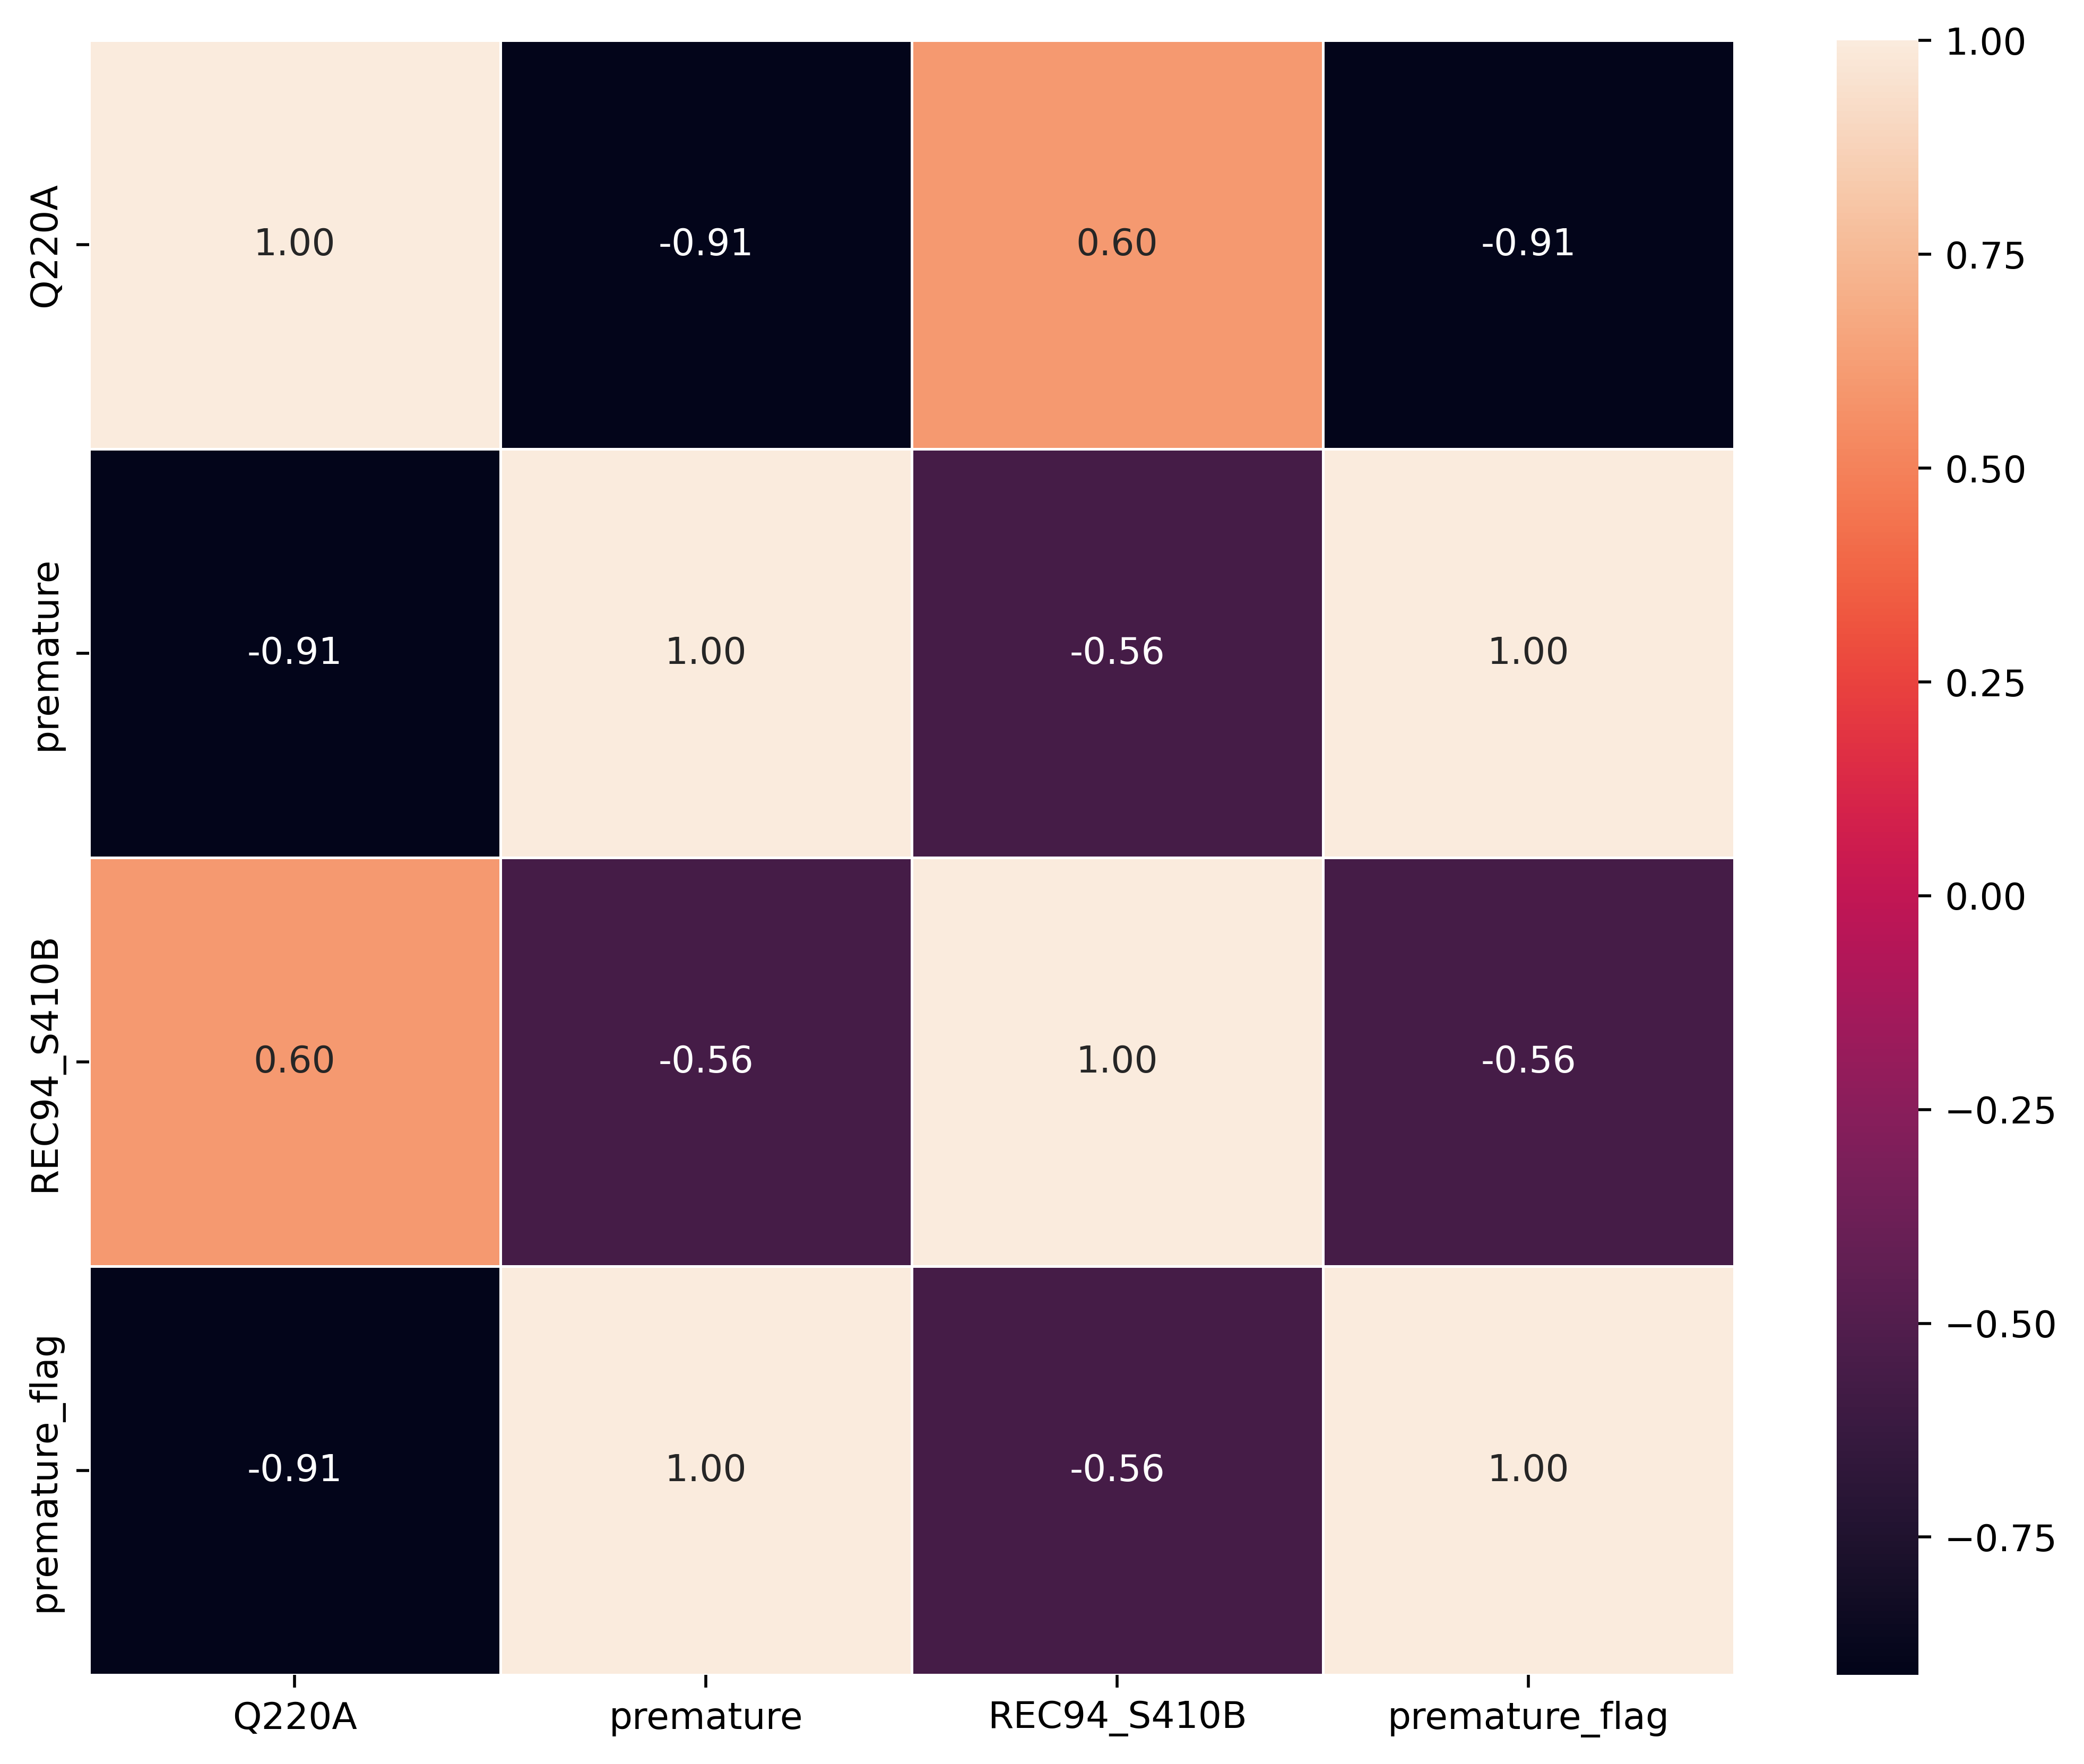

In [31]:
corr = tem_data_train[feature_corr].corr(method = 'pearson')
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [32]:
remove_columns =['HHID',
                 'CASEID',
                   'BIDX',
                     'Q220A',
                       'premature', 
                       'CASEID_HHID']
data_train =data_train.drop(columns=remove_columns)
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   premature_flag   18335 non-null  int64  
 1   REC91_V212       18335 non-null  float64
 2   REC91_V228       18335 non-null  int64  
 3   REC91_V218       18335 non-null  float64
 4   REC91_V208       18335 non-null  float64
 5   REC91_V217       18335 non-null  float64
 6   REC91_V364       18335 non-null  float64
 7   RE516171_V704    18335 non-null  float64
 8   RE516171_V715    18335 non-null  float64
 9   RE516171_V501    18335 non-null  float64
 10  RE516171_V716    18335 non-null  float64
 11  RE516171_V511    18335 non-null  float64
 12  RE516171_V631    18335 non-null  float64
 13  RE516171_V732    18335 non-null  float64
 14  RE516171_V504    18335 non-null  float64
 15  RE516171_V743F   18335 non-null  float64
 16  RE516171_V531    18335 non-null  float64
 17  RE516171_V52

In [33]:
data_train['premature_flag'].value_counts(1)

premature_flag
0    0.807254
1    0.192746
Name: proportion, dtype: float64

In [34]:
data_train.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   premature_flag   18335 non-null  int64  
 1   REC91_V212       18335 non-null  float64
 2   REC91_V228       18335 non-null  int64  
 3   REC91_V218       18335 non-null  float64
 4   REC91_V208       18335 non-null  float64
 5   REC91_V217       18335 non-null  float64
 6   REC91_V364       18335 non-null  float64
 7   RE516171_V704    18335 non-null  float64
 8   RE516171_V715    18335 non-null  float64
 9   RE516171_V501    18335 non-null  float64
 10  RE516171_V716    18335 non-null  float64
 11  RE516171_V511    18335 non-null  float64
 12  RE516171_V631    18335 non-null  float64
 13  RE516171_V732    18335 non-null  float64
 14  RE516171_V504    18335 non-null  float64
 15  RE516171_V743F   18335 non-null  float64
 16  RE516171_V531    18335 non-null  float64
 17  RE516171_V52

In [35]:
df_train_test , df_holdout = train_test_split(data_train, test_size=0.1, random_state=42)  # random_state for reproducibility

train_data, test_data, train_labels, test_labels,features = split_dataset(df_train_test, remove_columns=None, target_variable='premature_flag')

holdout_data = df_holdout[features]
holdout_labels= df_holdout['premature_flag']


Train shape: (12834, 81), Test shape: (3667, 81)
Train labels shape: (12834,), Test labels shape: (3667,)
Features used: 81


In [36]:
holdout_data.shape, holdout_labels.shape

((1834, 81), (1834,))

In [37]:
print(train_labels.value_counts(1)), 
print(test_labels.value_counts(1)), 
print(holdout_labels.value_counts(1)), 


premature_flag
0    0.80653
1    0.19347
Name: proportion, dtype: float64
premature_flag
0    0.806654
1    0.193346
Name: proportion, dtype: float64
premature_flag
0    0.813522
1    0.186478
Name: proportion, dtype: float64


(None,)

In [38]:
#result = rank_models(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)

In [39]:
#result

In [40]:
#result[['Model','dataset_type','Accuracy','Precision','F1 Score','KS Stat','ROC AUC'    ]]

In [56]:

def train_xgb_gridsearch_and_rank(train_data, 
                                  train_labels, 
                                  test_data, 
                                  test_labels, 
                                  holdout_data, 
                                  holdout_labels,
                                  param_grid,
                                  ):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    # Parameter grid (customize as needed)
    # param_grid = {
    #     #'n_estimators': [800,1000,1200],
    #     'n_estimators': [700],
    #     'max_depth': [ 3,6,9],
    #     'learning_rate': [0.01],
    #     'subsample': [0.8],
    #     'colsample_bytree': [0.8],
    #     'min_child_weight': [1],
    #     'gamma': [0]
    # }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, train_data, y_train, 'Training'),
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
       
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params

def train_xgb_gridsearch_and_rank_tresh(
    train_data, 
    train_labels, 
    test_data, 
    test_labels, 
    holdout_data, 
    holdout_labels,
    param_grid,
    threshold=0.6  # default threshold
):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    evaluates on Training, Test, and Holdout datasets using a custom threshold.
    Returns the trained model, metrics DataFrame, and best parameters.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # ---- Helper function for evaluation ----
    def evaluate(model, X, y, dataset_type, thr=threshold):
        probs = model.predict_proba(X)[:, 1]
        preds = (probs >= thr).astype(int)

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Threshold': thr,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on all datasets
    results = [
        evaluate(best_model, train_data, y_train, 'Training'),
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params





def train_xgb_with_early_stop(
    train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels,
    early_stopping_rounds=400
):
    """
    Train XGBoost model with early stopping and evaluate performance.
    """

    # Convert labels to 1D arrays
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle class imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"⚖️ Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Best parameters from your previous tuning
    params = {
        "objective": "binary:logistic",
        "eval_metric": ["logloss", "error"],  # track both metrics
        "random_state": 123,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.01,
        "max_depth": 3,
        "min_child_weight": 1,
        "n_estimators": 1000,
        "subsample": 0.8
    }

    model = xgb.XGBClassifier(**params)

    # Define eval set
    eval_set = [(train_data, y_train), (test_data, y_test)]

    # ✅ Train with early stopping
    model.fit(
        train_data, y_train,
        eval_set=eval_set,
        early_stopping_rounds=early_stopping_rounds,
        verbose=True
    )

    print(f"\n✅ Best iteration: {model.best_iteration}")
    print(f"✅ Best score: {model.best_score}\n")

    # --- Evaluation helper ---
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)
        ks_stat = ks_2samp(probs[y == 1], probs[y == 0]).statistic

        return {
            "Model": "XGBClassifier (EarlyStop)",
            "Dataset": dataset_type,
            "Accuracy": accuracy,
            "Recall": recall,
            "Precision": precision,
            "F1 Score": f1,
            "KS Stat": ks_stat,
            "ROC AUC": roc_auc
        }

    # Evaluate model on test and holdout
    results = [
        evaluate(model, test_data, y_test, "Test"),
        evaluate(model, holdout_data, y_holdout, "Holdout")
    ]
    results_df = pd.DataFrame(results).round(4)
    results_df["Rank"] = range(1, len(results_df) + 1)

    # --- Plot learning curves ---
    evals_result = model.evals_result()
    epochs = len(evals_result["validation_0"]["logloss"])
    x_axis = range(epochs)

    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, evals_result["validation_0"]["logloss"], label="Train")
    plt.plot(x_axis, evals_result["validation_1"]["logloss"], label="Test")
    plt.legend()
    plt.ylabel("Log Loss")
    plt.title("XGBoost Log Loss")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, evals_result["validation_0"]["error"], label="Train")
    plt.plot(x_axis, evals_result["validation_1"]["error"], label="Test")
    plt.legend()
    plt.ylabel("Classification Error")
    plt.title("XGBoost Classification Error")
    plt.show()

    return model, results_df



def train_xgb_gridsearch_and_rank_v2(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    # neg, pos = np.bincount(y_train)
    # scale_pos_weight = neg / pos
    # print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        #scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1000,1500,2000],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, train_data, y_train, 'Training'),
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
       
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params


def train_xgb_gridsearch_and_rank_v3(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    # neg, pos = np.bincount(y_train)
    # scale_pos_weight = neg / pos
    # print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        #scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )
    

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1000,1500,2000],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        #'subsample': [0.7, 0.8, 1.0],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params


def train_xgb_gridsearch_and_rank_v4(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        tree_method="hist",
        grow_policy="lossguide"
    )

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1200,1600],
        'max_depth': [ 3,5,7],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params


In [42]:
def perm_importance_test(
    model,
    test_data,
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
):
    """
    Compute permutation importance for a trained model using only the Test dataset.

    Parameters
    ----------
    model : fitted model
        Any trained sklearn-compatible model with .predict_proba().
    test_data : DataFrame
        Features of the test dataset.
    test_labels : Series or array
        Target labels for the test dataset.
    scoring : str, default='roc_auc'
        Metric to evaluate permutation importance.
    n_repeats : int, default=10
        Number of shuffles per feature.
    random_state : int, default=42
        Seed for reproducibility.

    Returns
    -------
    df_imp : DataFrame
        Feature importance ranked by mean decrease in performance.
        Columns: ['rank', 'feature', 'importance_mean', 'importance_std']
    result : sklearn permutation_importance object
        Full result for advanced analysis or plotting.
    """

    # Ensure correct label shape
    y_test = np.ravel(test_labels)

    print("🔹 Computing permutation importance on TEST set...")
    result = permutation_importance(
        model,
        test_data,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    # Build importance DataFrame
    df_rank = pd.DataFrame({
        "feature": test_data.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    df_rank["rank"] = np.arange(1, len(df_rank) + 1)
    df_rank = df_rank[["rank", "feature", "importance_mean", "importance_std"]]

    print("✅ Permutation importance completed on TEST dataset.")
    return df_rank, result


In [43]:
def model_curve_plot_logloss_error(model, train_data, train_labels, test_data, test_labels):
    """
    Train an XGBoost model and plot LogLoss and Classification Error
    curves for Train vs. Test sets.
    """

    # Force model to track logloss + error
    model.set_params(eval_metric=["logloss", "error"])

    eval_set = [(train_data, train_labels), (test_data, test_labels)]

    # Fit model
    model.fit(train_data, train_labels, eval_set=eval_set, verbose=True)

    # Evaluate accuracy
    preds = model.predict(test_data)
    acc = accuracy_score(test_labels, preds)
    print(f"✅ Test Accuracy: {acc * 100:.2f}%")

    # Retrieve metrics
    results = model.evals_result()
    print(f"Available metrics: {list(results['validation_0'].keys())}")

    # Plot Log Loss
    epochs = len(results['validation_0']['logloss'])
    x_axis = range(0, epochs)
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
    plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
    plt.legend()
    plt.xlabel('Boosting Rounds')
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss Curve')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    # Plot Classification Error
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, results['validation_0']['error'], label='Train')
    plt.plot(x_axis, results['validation_1']['error'], label='Test')
    plt.legend()
    plt.xlabel('Boosting Rounds')
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error Curve')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    return plt.show()




# cenario 1 

In [44]:
#new 

    # Parameter grid (customize as needed)
param_grid = {
        #'n_estimators': [800,1000,1200],
        'n_estimators': [700],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }
model_1, results_df_1, best_params_1 =  train_xgb_gridsearch_and_rank(train_data, 
                                                                      train_labels,
                                                                      test_data,
                                                                    test_labels,
                                                                    holdout_data,
                                                                    holdout_labels,
                                                                    param_grid)
results_df_1

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:30:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 9
   min_child_weight: 1
   n_estimators: 700
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.9756


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:30:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Training,0.9832,1.0000,0.9203,0.9585,0.9915,0.9998,1
1,XGBClassifier (GridSearch),Test,0.9269,0.9210,0.7549,0.8297,0.8729,0.9765,2
2,XGBClassifier (GridSearch),Holdout,0.9177,0.9298,0.7146,0.8081,0.8482,0.9733,3


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


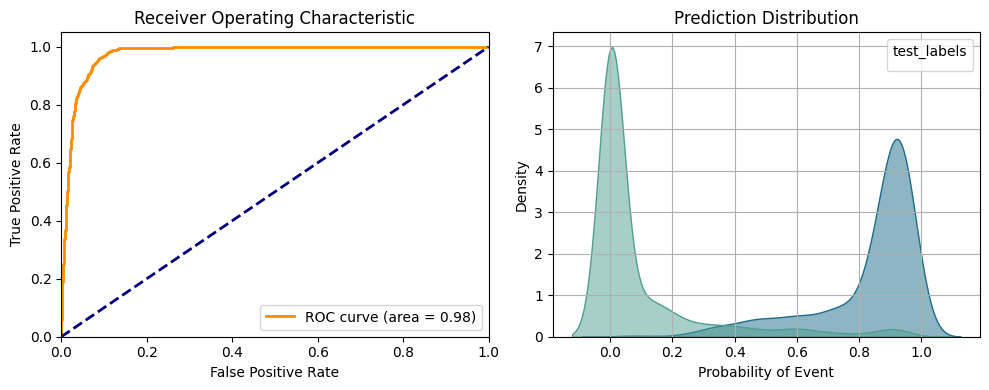

In [45]:
# new 
plot_roc_curve_from_df(model_1, test_labels, test_data, 5)

In [46]:

df_rank_model_1, result_model_1 = perm_importance_test(
    model_1,
    test_data,
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
df_rank_model_1

🔹 Computing permutation importance on TEST set...
✅ Permutation importance completed on TEST dataset.


,rank,feature,importance_mean,importance_std
0,1,REC94_S410B,0.273263,0.007169
1,2,REC41_M44,0.030043,0.001078
2,3,RE516171_V504,0.008280,0.000575
3,4,RE516171_V743A,0.006448,0.000370
4,5,REC94_S411J,0.005511,0.000296
5,6,REC94_QI422A_B,0.004690,0.000441
6,7,RE516171_V732,0.003714,0.000601
7,8,REC41_M14,0.003521,0.000284
8,9,RE516171_V743E,0.002216,0.000367
9,10,REC94_QI422A_C,0.002156,0.000322


In [47]:
save_file(df_rank_model_1, dir = "outputs\\reports", output_file = "df_rank_model_1_22102025.csv")

# cenario 2 - Reduzin N estimator and Max depth. 

In [48]:
#new 
param_grid = {
        #'n_estimators': [800,1000,1200],
        'n_estimators': [650],
        'max_depth': [ 1,2],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }


model_2, results_df_2, best_params_2 =  train_xgb_gridsearch_and_rank(train_data,
                                                                       train_labels,
                                                                        test_data, 
                                                                        test_labels, 
                                                                        holdout_data, 
                                                                        holdout_labels,
                                                                        param_grid)
results_df_2

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:31:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 2
   min_child_weight: 1
   n_estimators: 650
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.9328


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:31:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Training,0.8676,0.8602,0.6124,0.7155,0.7570,0.9394,1
1,XGBClassifier (GridSearch),Test,0.8639,0.8364,0.6076,0.7039,0.7491,0.9301,2
2,XGBClassifier (GridSearch),Holdout,0.8468,0.8333,0.5599,0.6698,0.7143,0.9202,3


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


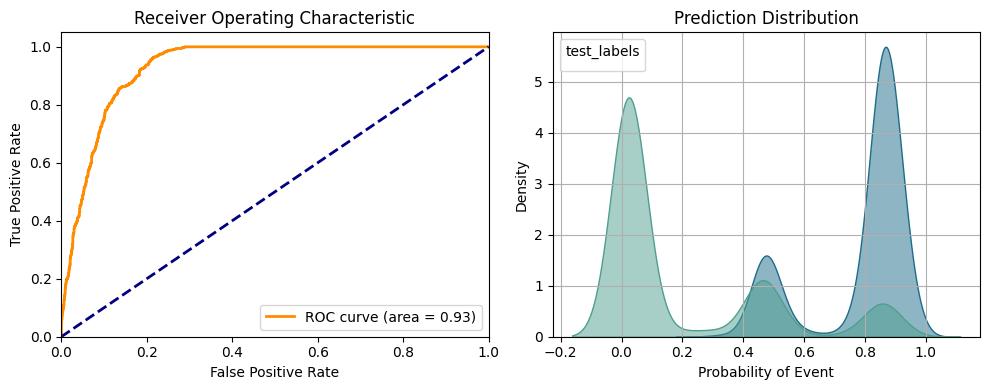

In [49]:
plot_roc_curve_from_df(model_2, test_labels, test_data, 5)

In [50]:

df_rank_model_2, result_model_2 = perm_importance_test(
    model_2,
    test_data,
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
df_rank_model_2

🔹 Computing permutation importance on TEST set...
✅ Permutation importance completed on TEST dataset.


,rank,feature,importance_mean,importance_std
0,1,REC94_S410B,3.652022e-01,9.336706e-03
1,2,REC41_M44,2.795980e-02,1.136018e-03
2,3,REC41_M14,5.767940e-03,6.421769e-04
3,4,REC94_S411J,2.889179e-03,5.706187e-04
4,5,REC94_QI422A_B,2.467979e-03,7.552377e-04
5,6,RE516171_V631,2.221725e-03,3.605487e-04
6,7,REC94_S411K,1.656405e-03,8.988111e-04
7,8,REC94_S411I,1.501319e-03,2.191354e-04
8,9,RE516171_V504,1.384522e-03,1.013300e-04
9,10,REC41_M42C,1.301269e-03,4.169889e-05


In [51]:
save_file(df_rank_model_2, dir = "outputs\\reports", output_file = "df_rank_model_2_22102025.csv")

# model 3-  best features

In [52]:
df_rank_model_3 = df_rank_model_2[df_rank_model_2['importance_mean'] > 0]['feature'].to_list()

# Safely remove elements only if they exist
for col in ['REC41_M19A', 'RE516171_V702', 'CSALUD01_QS22A']:
    if col in df_rank_model_3:
        df_rank_model_3.remove(col)

len(df_rank_model_3)

47

In [53]:
param_grid = {
        #'n_estimators': [800,1000,1200],
        'n_estimators': [650],
        'max_depth': [ 1,2],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }


model_3, results_df_3, best_params_3 =  train_xgb_gridsearch_and_rank(train_data[df_rank_model_3],
                                                                       train_labels,
                                                                        test_data[df_rank_model_3], 
                                                                        test_labels, 
                                                                        holdout_data[df_rank_model_3], 
                                                                        holdout_labels,
                                                                        param_grid)
results_df_3

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:31:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 2
   min_child_weight: 1
   n_estimators: 650
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.9327


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:31:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Training,0.8651,0.8659,0.6060,0.7130,0.7541,0.9387,1
1,XGBClassifier (GridSearch),Test,0.8623,0.8378,0.6037,0.7017,0.7431,0.9295,2
2,XGBClassifier (GridSearch),Holdout,0.8441,0.8392,0.5541,0.6674,0.7106,0.9201,3


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


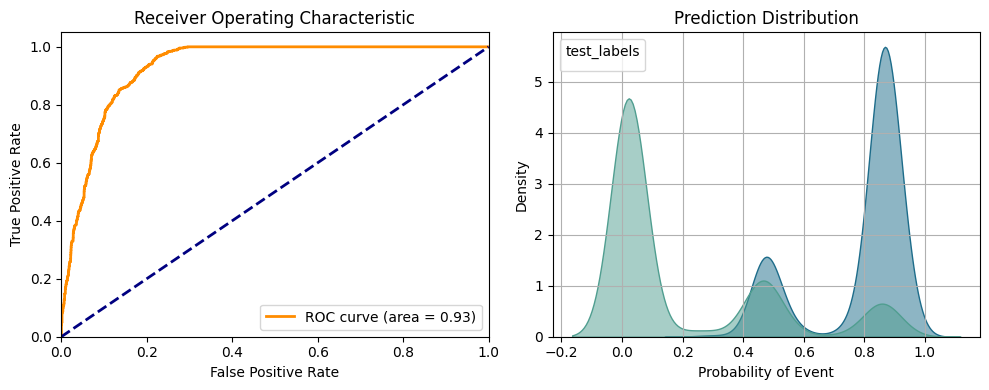

In [54]:
plot_roc_curve_from_df(model_3, test_labels, test_data[df_rank_model_3], 5)

# cenario 4 - impruve overfittinf

In [61]:
param_grid = {
        #'n_estimators': [800,1000,1200],
        'n_estimators': [650],
        'max_depth': [ 1,2],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }


# param_grid = {
#     'n_estimators': [400, 550],
#     'max_depth': [2, 3],
#     'learning_rate': [0.02],
#     'subsample': [0.8],
#     'colsample_bytree': [ 0.8],
#     'min_child_weight': [3, 5],  # stronger regularization on leaves
#     'gamma': [0, 0.1],         # penalize complex splits
#     'reg_lambda': [1, 3],        # L2 regularization
#     'reg_alpha': [0, 1]          # L1 regularization (sparse weights)

#     }
    


model_4, results_df_4, best_params_4 =  train_xgb_gridsearch_and_rank_tresh(train_data[df_rank_model_3],
                                                                       train_labels,
                                                                        test_data[df_rank_model_3], 
                                                                        test_labels, 
                                                                        holdout_data[df_rank_model_3], 
                                                                        holdout_labels,
                                                                        param_grid,
                                                                        threshold=0.65)
results_df_4

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:44:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 2
   min_child_weight: 1
   n_estimators: 650
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.9327


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:44:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Threshold,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Training,0.65,0.8738,0.8107,0.6364,0.7131,0.7541,0.9387,1
1,XGBClassifier (GridSearch),Test,0.65,0.8721,0.7842,0.6376,0.7034,0.7431,0.9295,2
2,XGBClassifier (GridSearch),Holdout,0.65,0.8604,0.7836,0.5956,0.6768,0.7106,0.9201,3


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


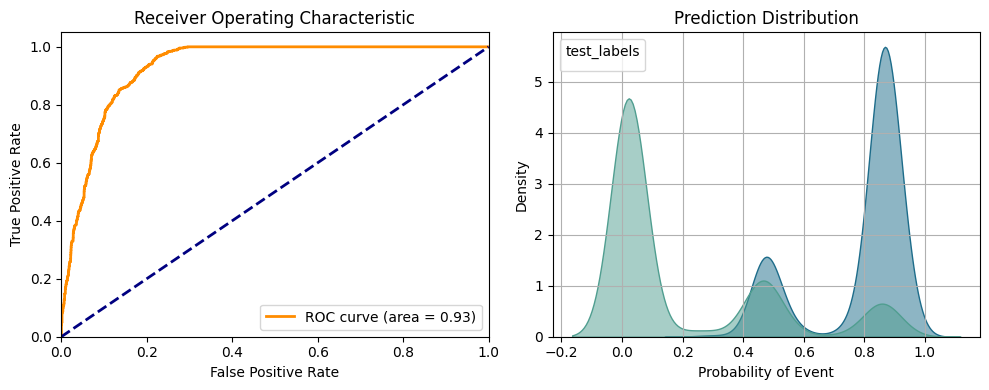

In [62]:
plot_roc_curve_from_df(model_4, test_labels, test_data[df_rank_model_3], 5)

In [63]:

df_rank_model_4, result_model_1 = perm_importance_test(
    model_4,
    test_data[df_rank_model_3],
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
df_rank_model_4

🔹 Computing permutation importance on TEST set...
✅ Permutation importance completed on TEST dataset.


,rank,feature,importance_mean,importance_std
0,1,REC94_S410B,0.367165,0.009396
1,2,REC41_M44,0.028345,0.001163
2,3,REC41_M14,0.005637,0.000713
3,4,REC94_S411J,0.002904,0.000551
4,5,REC94_QI422A_B,0.002305,0.000810
5,6,RE516171_V631,0.001770,0.000374
6,7,REC94_S411K,0.001612,0.000954
7,8,RE516171_V504,0.001323,0.000092
8,9,REC41_M42C,0.001239,0.000037
9,10,REC94_S411I,0.000904,0.000226


In [64]:
save_file(df_rank_model_4, dir = "outputs\\reports", output_file = "df_rank_model_4_22102025.csv")

In [79]:
import os
import pickle
from datetime import datetime

def save_model_pickle_fixed(model, output_file="xgb_propensity.pkl"):
    """
    Save a trained model as a .pkl file in:
    C:\\Users\\linoc\\OneDrive\\Encoder\\03_partos\\02_scripts\\Premature_model\\outputs\\models
    
    Args:
        model: Trained model object (e.g., XGBClassifier, sklearn model).
        output_file (str): Base filename for the pickle file.
    """

    # Fixed target directory
    output_dir = r"C:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\outputs\models"
    os.makedirs(output_dir, exist_ok=True)

    # Timestamped filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename, ext = os.path.splitext(output_file)
    output_file = f"{filename}_{timestamp}.pkl"

    # Full path
    output_path = os.path.join(output_dir, output_file)

    # Save model
    with open(output_path, "wb") as f:
        pickle.dump(model, f)

    print(f"✅ Model saved successfully at: {output_path}")
    return output_path


save_model_pickle_fixed(model_4, output_file="trained_model_4.pkl")

✅ Model saved successfully at: C:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\outputs\models\trained_model_4_20251022_141748.pkl


'C:\\Users\\linoc\\OneDrive\\Encoder\\03_partos\\02_scripts\\Premature_model\\outputs\\models\\trained_model_4_20251022_141748.pkl'

In [ ]:
# def score_full_dataset_with_features(model, data, target_variable='premature_flag', threshold=0.65):
#     """
#     Scores the full dataset using a trained XGBoost model.
#     Keeps all original features and appends:
#         - 'actual' (true label)
#         - 'pred_prob' (predicted probability)
#         - 'pred_label' (binary prediction at threshold)
#     """

#     # Copy to avoid altering original
#     df = data.copy()

#     # Ensure target variable exists
#     if target_variable not in df.columns:
#         raise ValueError(f"Target variable '{target_variable}' not found in dataframe.")

#     # Extract features and target
#     X = df.drop(columns=[target_variable])
#     y = df[target_variable]

#     # Predict probabilities and labels
#     probs = model.predict_proba(X)[:, 1]
#     preds = (probs >= threshold).astype(int)

#     # Add results while keeping all features
#     df['actual'] = y
#     df['pred_prob'] = probs
#     df['pred_label'] = preds

#     return df


In [71]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   premature_flag   18335 non-null  int64  
 1   REC91_V212       18335 non-null  float64
 2   REC91_V228       18335 non-null  int64  
 3   REC91_V218       18335 non-null  float64
 4   REC91_V208       18335 non-null  float64
 5   REC91_V217       18335 non-null  float64
 6   REC91_V364       18335 non-null  float64
 7   RE516171_V704    18335 non-null  float64
 8   RE516171_V715    18335 non-null  float64
 9   RE516171_V501    18335 non-null  float64
 10  RE516171_V716    18335 non-null  float64
 11  RE516171_V511    18335 non-null  float64
 12  RE516171_V631    18335 non-null  float64
 13  RE516171_V732    18335 non-null  float64
 14  RE516171_V504    18335 non-null  float64
 15  RE516171_V743F   18335 non-null  float64
 16  RE516171_V531    18335 non-null  float64
 17  RE516171_V52

In [76]:
# score_full_dataset_with_features = score_all_datasets(model_4, 
#                        train_data[df_rank_model_3], train_labels, 
#                        test_data[df_rank_model_3], test_labels, 
#                        holdout_data[df_rank_model_3], holdout_labels,
#                        threshold=0.65)


# df_rank_model_3_flag = df_rank_model_3.copy()
# df_rank_model_3_flag .append('premature_flag')

# score_full_dataset_with_features(model_4, 
#                                  data_train[df_rank_model_3_flag], target_variable='premature_flag', threshold=0.6)


# score_full_dataset_with_features.info()

In [ ]:
df_rank_model_3_flag
